In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error,r2_score

import warnings
warnings.filterwarnings('ignore')


In [2]:
df=pd.read_csv(r"C:\Data\Machine Learning\Machine_learning\Data\insurance.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
#print first five rows
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.shape

(1338, 7)

In [6]:
#check for any missing value
print("\nMissing values in each column:", df.isnull().sum())

# Check for duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())

# Drop duplicates (usually there is 1 duplicate row in this dataset)
df = df.drop_duplicates()
print("Shape after dropping duplicates:", df.shape)


Missing values in each column: age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Number of duplicate rows: 1
Shape after dropping duplicates: (1337, 7)


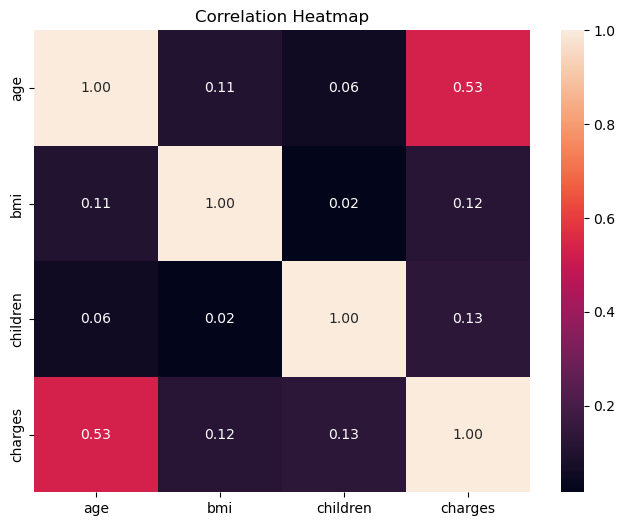

In [7]:
# Correlation heatmap for numerical features using Spearman correlation
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(method='spearman', numeric_only=True), annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

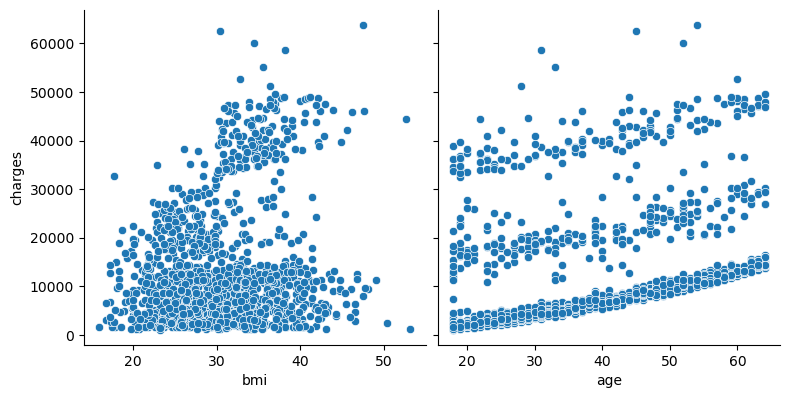

In [8]:
sns.pairplot(df, x_vars=[ 'bmi','age'], y_vars ='charges', height=4, aspect=1, kind='scatter')
plt.show()

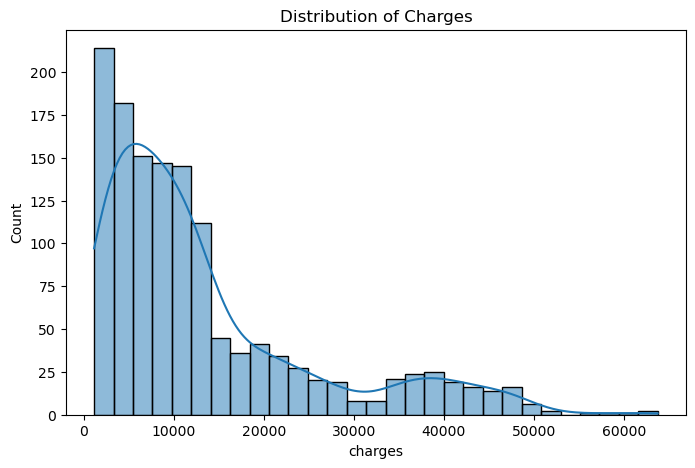

In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(df['charges'], kde=True)
plt.title("Distribution of Charges")
plt.show()

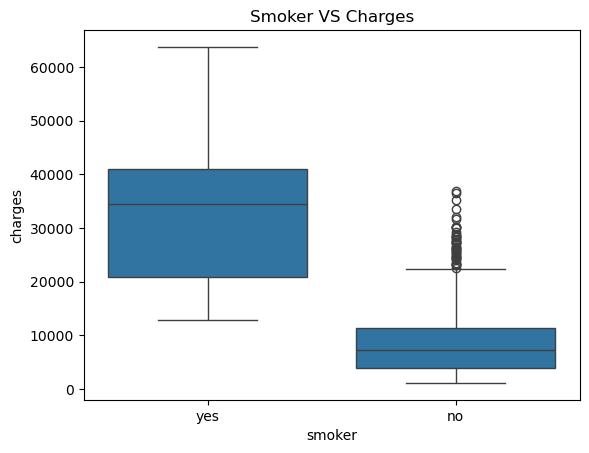

In [10]:
sns.boxplot(x = 'smoker', y = 'charges', data=df)
plt.title("Smoker VS Charges")
plt.show()

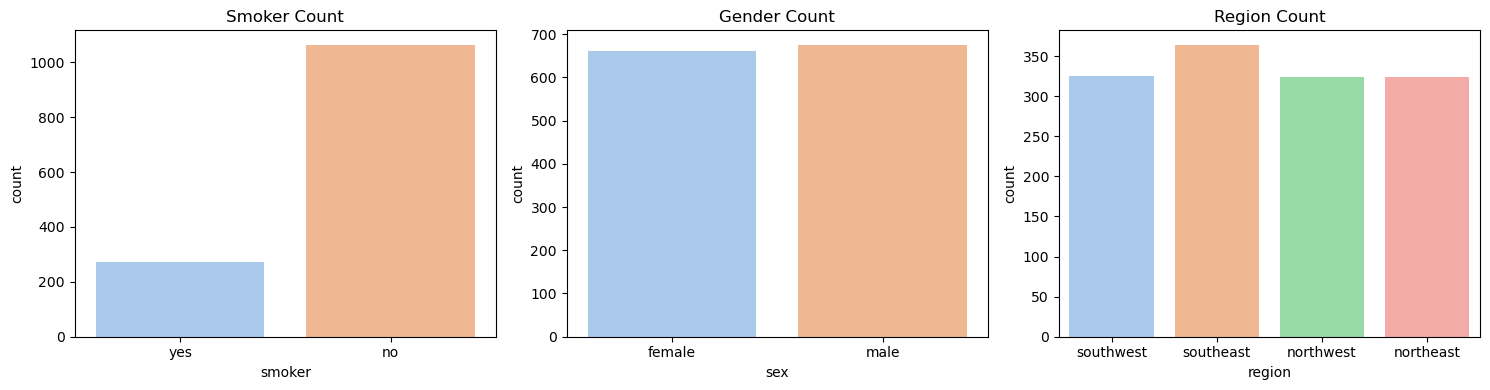

In [11]:
# Count plots for categorical variables
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(x='smoker', data=df, ax=axes[0], palette='pastel').set_title("Smoker Count")
sns.countplot(x='sex', data=df, ax=axes[1], palette='pastel').set_title("Gender Count")
sns.countplot(x='region', data=df, ax=axes[2], palette='pastel').set_title("Region Count")
plt.tight_layout()
plt.show()

In [12]:
# Encoding binary categorical variables (sex, smoker)
df['sex'] = df['sex'].map({'male': 1, 'female': 0})
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})

# One-Hot Encoding for 'region' (creates dummy variables)
df = pd.get_dummies(df, columns=['region'], drop_first=True)

df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


In [13]:
#train Test split
X= df.drop(['charges'], axis=1)
y=df['charges']
X_train,X_test, y_train, y_test= train_test_split(X, y, test_size=0.30,random_state=42)


In [14]:
scaler = StandardScaler()

# Fit only on training data to prevent data leakage, then transform both
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model=linear_model.LinearRegression()
lr=model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("RMSE: ", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-squared: ", r2_score(y_test,y_pred))

RMSE:  6240.205919905714
R-squared:  0.7724363518631285


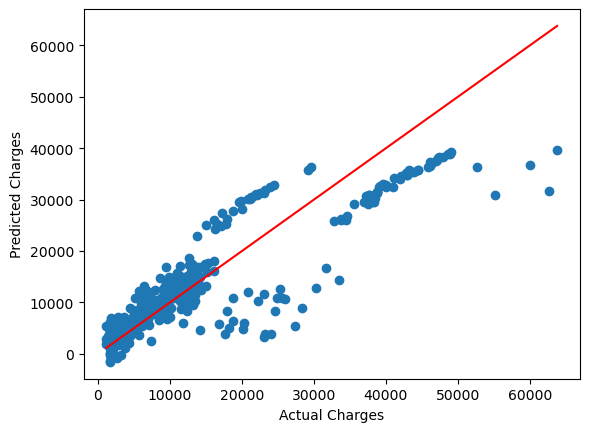

In [15]:
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.show()
